In [1]:
"""
Part 1.3 Data Analysis
Two models: Random Forest and Naive Bayes 

"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fairlearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE


In [2]:
# DATASET 1: Credit Card Fraud Detection

# Load dataset
df1 = pd.read_csv('creditcard.csv')

print(f"Dataset shape: {df1.shape}")
print(f"Fraud cases: {df1['Class'].sum()} ({df1['Class'].mean() * 100:.3f}%)")

# Separate features and target
X1 = df1.drop('Class', axis=1)
y1 = df1['Class']

# Scale Time and Amount
scaler1 = StandardScaler()
X1[['Time', 'Amount']] = scaler1.fit_transform(
    X1[['Time', 'Amount']]
)

# Split data into training and testing sets
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

# Handle class imbalance using SMOTE on training data
sm = SMOTE(random_state=42)
X1_train_sm, y1_train_sm = sm.fit_resample(
    X1_train,
    y1_train
)

# Random Forest
rf1 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf1.fit(X1_train_sm, y1_train_sm)

rf1_pred = rf1.predict(X1_test)
rf1_proba = rf1.predict_proba(X1_test)[:, 1]

print("\nRandom Forest - Dataset 1")
print(f"Precision: {precision_score(y1_test, rf1_pred):.4f}")
print(f"Recall:    {recall_score(y1_test, rf1_pred):.4f}")
print(f"F1-score:  {f1_score(y1_test, rf1_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y1_test, rf1_proba):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y1_test, rf1_pred))

# Naive Bayes
nb1 = GaussianNB()

nb1.fit(X1_train_sm, y1_train_sm)

nb1_pred = nb1.predict(X1_test)
nb1_proba = nb1.predict_proba(X1_test)[:, 1]

print("\nNaive Bayes - Dataset 1")
print(f"Precision: {precision_score(y1_test, nb1_pred):.4f}")
print(f"Recall:    {recall_score(y1_test, nb1_pred):.4f}")
print(f"F1-score:  {f1_score(y1_test, nb1_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y1_test, nb1_proba):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y1_test, nb1_pred))

Dataset shape: (284807, 31)
Fraud cases: 492 (0.173%)

Random Forest - Dataset 1
Precision: 0.8454
Recall:    0.8367
F1-score:  0.8410
ROC-AUC:   0.9731
Confusion Matrix:
[[56849    15]
 [   16    82]]

Naive Bayes - Dataset 1
Precision: 0.0550
Recall:    0.8776
F1-score:  0.1035
ROC-AUC:   0.9644
Confusion Matrix:
[[55386  1478]
 [   12    86]]


In [3]:
# DATASET 2: Stock Price and Volume (AAPL)

print("DATASET 2: AAPL Stock Price and Volume")

# Load and sort the data by date
df2 = pd.read_csv("aapl.us.txt")
df2["Date"] = pd.to_datetime(df2["Date"])
df2 = df2.sort_values("Date").reset_index(drop=True)

# Feature engineering
df2["DailyChangePct"] = (df2["Close"] - df2["Open"]) / df2["Open"] * 100
df2["HighLowSpread"] = (df2["High"] - df2["Low"]) / df2["Low"] * 100
df2["VolumeChangePct"] = df2["Volume"].pct_change() * 100
df2["PrevClose"] = df2["Close"].shift(1)
df2["PrevVolume"] = df2["Volume"].shift(1)

# Target: 1 if tomorrow's closing price is higher, otherwise 0
df2["NextClose"] = df2["Close"].shift(-1)
df2["Target"] = (df2["NextClose"] > df2["Close"]).astype(int)

# Remove missing and infinite values
df2 = df2.replace([np.inf, -np.inf], np.nan)
df2 = df2.dropna().reset_index(drop=True)

# Select features and target
features2 = [
    "Open", "High", "Low", "Close", "Volume",
    "DailyChangePct", "HighLowSpread", "VolumeChangePct",
    "PrevClose", "PrevVolume"
]

X2 = df2[features2]
y2 = df2["Target"]

# Split chronologically to avoid using future data
split_idx = int(len(X2) * 0.8)

X2_train = X2.iloc[:split_idx]
X2_test = X2.iloc[split_idx:]
y2_train = y2.iloc[:split_idx]
y2_test = y2.iloc[split_idx:]

# Scale features using only the training data
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

# Random Forest
rf2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf2.fit(X2_train_scaled, y2_train)

rf2_pred = rf2.predict(X2_test_scaled)
rf2_proba = rf2.predict_proba(X2_test_scaled)[:, 1]

rf2_precision = precision_score(y2_test, rf2_pred, zero_division=0)
rf2_recall = recall_score(y2_test, rf2_pred, zero_division=0)
rf2_f1 = f1_score(y2_test, rf2_pred, zero_division=0)
rf2_auc = roc_auc_score(y2_test, rf2_proba)

print("\nRandom Forest Results")
print(f"Precision: {rf2_precision:.4f}")
print(f"Recall:    {rf2_recall:.4f}")
print(f"F1-score:  {rf2_f1:.4f}")
print(f"ROC-AUC:   {rf2_auc:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y2_test, rf2_pred))

# Naive Bayes
nb2 = GaussianNB()

nb2.fit(X2_train_scaled, y2_train)

nb2_pred = nb2.predict(X2_test_scaled)
nb2_proba = nb2.predict_proba(X2_test_scaled)[:, 1]

nb2_precision = precision_score(y2_test, nb2_pred, zero_division=0)
nb2_recall = recall_score(y2_test, nb2_pred, zero_division=0)
nb2_f1 = f1_score(y2_test, nb2_pred, zero_division=0)
nb2_auc = roc_auc_score(y2_test, nb2_proba)

print("\nNaive Bayes Results")
print(f"Precision: {nb2_precision:.4f}")
print(f"Recall:    {nb2_recall:.4f}")
print(f"F1-score:  {nb2_f1:.4f}")
print(f"ROC-AUC:   {nb2_auc:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y2_test, nb2_pred))

# Random Forest feature importance
importances = pd.Series(
    rf2.feature_importances_,
    index=features2
).sort_values(ascending=False)

print("\nRandom Forest Feature Importance")
print(importances)

DATASET 2: AAPL Stock Price and Volume

Random Forest Results
Precision: 0.5259
Recall:    0.2106
F1-score:  0.3007
ROC-AUC:   0.4861
Confusion Matrix:
[[639 165]
 [686 183]]

Naive Bayes Results
Precision: 0.5194
Recall:    1.0000
F1-score:  0.6837
ROC-AUC:   0.4952
Confusion Matrix:
[[  0 804]
 [  0 869]]

Random Forest Feature Importance
VolumeChangePct    0.120610
PrevVolume         0.119930
DailyChangePct     0.117978
HighLowSpread      0.117845
Volume             0.117679
PrevClose          0.084144
Close              0.081646
Open               0.080591
High               0.079807
Low                0.079769
dtype: float64


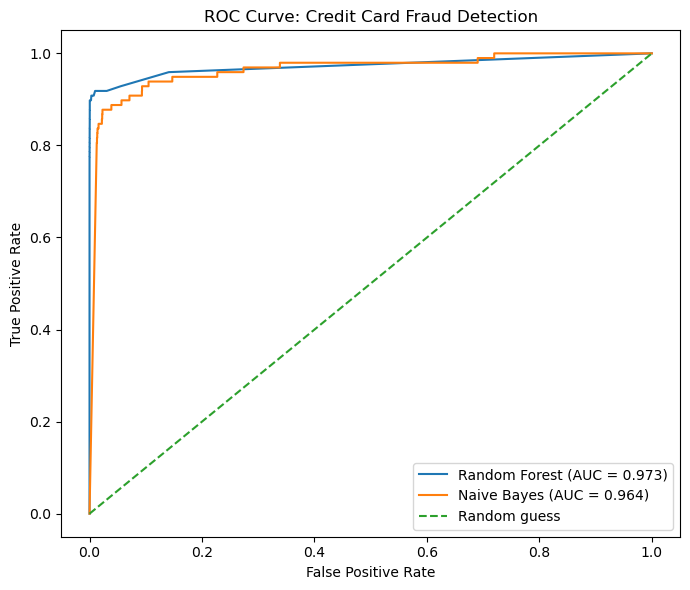

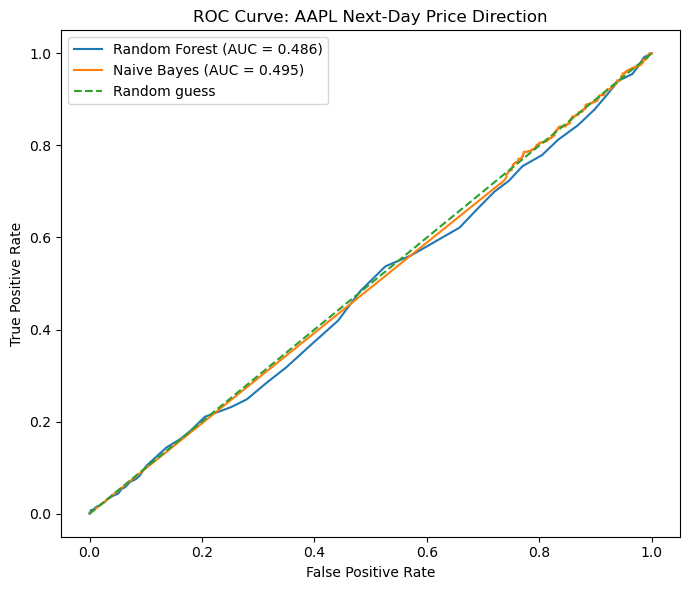

In [4]:

# ROC CURVES for Dataset 1: Credit Card Fraud

fpr_rf1, tpr_rf1, thresholds_rf1 = roc_curve(y1_test, rf1_proba)
fpr_nb1, tpr_nb1, thresholds_nb1 = roc_curve(y1_test, nb1_proba)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_rf1,
    tpr_rf1,
    label=f"Random Forest (AUC = {roc_auc_score(y1_test, rf1_proba):.3f})"
)

plt.plot(
    fpr_nb1,
    tpr_nb1,
    label=f"Naive Bayes (AUC = {roc_auc_score(y1_test, nb1_proba):.3f})"
)

plt.plot([0, 1], [0, 1], "--", label="Random guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Credit Card Fraud Detection")
plt.legend()
plt.tight_layout()

plt.show()


# ROC CURVES for Dataset 2: AAPL Stock Direction

fpr_rf2, tpr_rf2, _ = roc_curve(y2_test, rf2_proba)
fpr_nb2, tpr_nb2, _ = roc_curve(y2_test, nb2_proba)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_rf2,
    tpr_rf2,
    label=f"Random Forest (AUC = {roc_auc_score(y2_test, rf2_proba):.3f})"
)

plt.plot(
    fpr_nb2,
    tpr_nb2,
    label=f"Naive Bayes (AUC = {roc_auc_score(y2_test, nb2_proba):.3f})"
)

plt.plot([0, 1], [0, 1], "--", label="Random guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: AAPL Next-Day Price Direction")
plt.legend()
plt.tight_layout()

plt.show()

Generating learning curve...
Generating learning curve (SMOTE applied inside each fold, no leakage)...


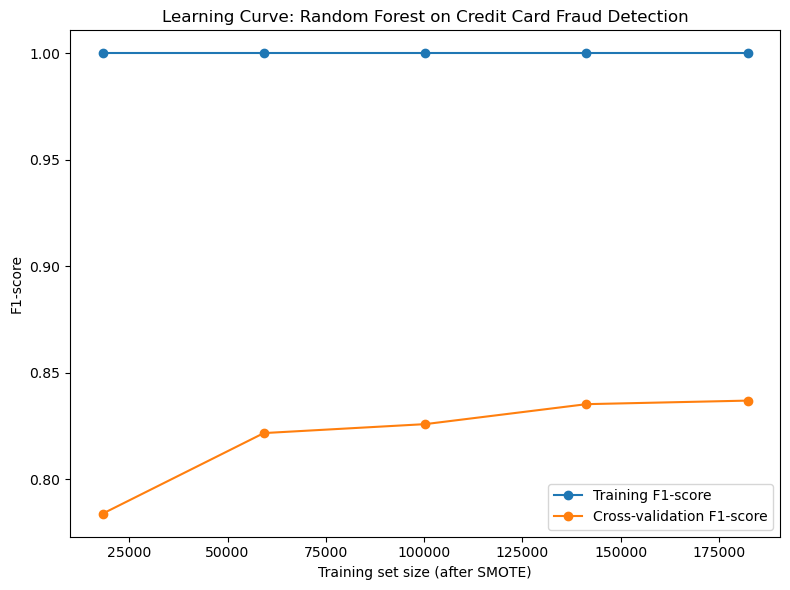


Final training F1: 1.0000
Final validation F1: 0.8370
Train-validation gap: 0.1630

Running fairness analysis...

--- Fairness metrics by transaction amount tier ---
        precision    recall  f1_score  selection_rate
Amount                                               
High     0.941176  0.842105  0.888889        0.001791
Low      0.820000  0.836735  0.828283        0.002553
Medium   0.692308  0.818182  0.750000        0.000707

--- Fairness disparity summary ---
Max precision difference across groups: 0.2489
Max recall difference across groups: 0.0239


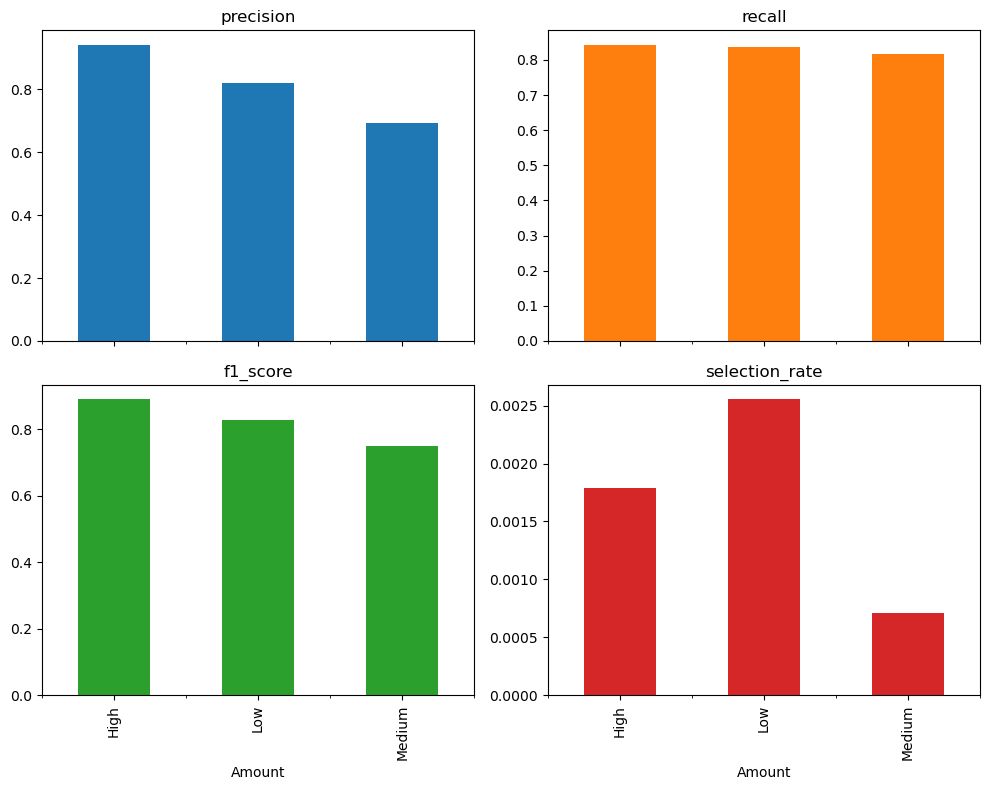

In [5]:
"""
Task 2, Part 2: Learning Curve + Bias/Fairness Analysis
Run this after your existing Dataset 1 (Credit Card Fraud) code above.
"""

from sklearn.model_selection import learning_curve, StratifiedKFold
from fairlearn.metrics import MetricFrame, selection_rate
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ===========================================================
# Point 2: Learning Curve
# ===========================================================
print("Generating learning curve...")

# StratifiedKFold used here (not plain KFold) because fraud is only 0.17%
# of the data, a random fold could easily contain zero fraud cases otherwise
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Generating learning curve (SMOTE applied inside each fold, no leakage)...")

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# SMOTE now runs INSIDE the pipeline, separately for each fold,
# so no synthetic point ever leaks between train and validation
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=1))
])

train_sizes, train_scores, val_scores = learning_curve(
    estimator=pipeline,
    X=X1_train,        
    y=y1_train,
    cv=cv_strategy,
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 5),  
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', label='Training F1-score', color='#1f77b4')
plt.plot(train_sizes, val_mean, 'o-', label='Cross-validation F1-score', color='#ff7f0e')
plt.xlabel('Training set size (after SMOTE)')
plt.ylabel('F1-score')
plt.title('Learning Curve: Random Forest on Credit Card Fraud Detection')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('learning_curve_creditcard.png', dpi=200)
plt.show()

print(f"\nFinal training F1: {train_mean[-1]:.4f}")
print(f"Final validation F1: {val_mean[-1]:.4f}")
print(f"Train-validation gap: {train_mean[-1] - val_mean[-1]:.4f}")


# ===========================================================
# Point 3: Bias / Fairness Analysis using Fairlearn (Microsoft)
# ===========================================================
print("\nRunning fairness analysis...")

# The dataset has no demographic columns (V1-V28 are PCA-anonymised
# specifically to remove identifying information). As a defensible proxy
# sensitive attribute, we bin transaction Amount into tiers, checking
# whether fraud detection performance differs by transaction size,
# a genuine fairness concern (e.g. could disadvantage customers who
# typically transact in smaller amounts).

amount_original = df1.loc[X1_test.index, 'Amount']
amount_bins = pd.qcut(amount_original, q=3, labels=['Low', 'Medium', 'High'])

metric_frame = MetricFrame(
    metrics={
        'precision': precision_score,
        'recall': recall_score,
        'f1_score': f1_score,
        'selection_rate': selection_rate
    },
    y_true=y1_test,
    y_pred=rf1_pred,
    sensitive_features=amount_bins
)

print("\n--- Fairness metrics by transaction amount tier ---")
print(metric_frame.by_group)

print("\n--- Fairness disparity summary ---")
print(f"Max precision difference across groups: {metric_frame.difference()['precision']:.4f}")
print(f"Max recall difference across groups: {metric_frame.difference()['recall']:.4f}")

metric_frame.by_group.plot.bar(subplots=True, layout=(2, 2), figsize=(10, 8), legend=False)
plt.tight_layout()
plt.savefig('fairness_by_amount_tier.png', dpi=200)
plt.show()